# Notebook 8: Generative Models — VAE and DDPM Diffusion
**UCU Deep Learning Course**

In Notebook 7 we built a decoder-only transformer that **generates text** by sampling one token at a time from a learned distribution over the next character. That was already a generative model — but a *sequential, autoregressive* one. In this notebook we step into two very different ways of modelling a data distribution, both for **images**:

1. **Variational Autoencoders (VAEs)** — encode an image to a low-dimensional Gaussian latent, decode back, and train with the **ELBO** (reconstruction + KL).
2. **Denoising Diffusion Probabilistic Models (DDPM)** — corrupt an image with Gaussian noise over $T$ steps, then train a U-Net to undo the corruption one step at a time.

Both will be built **from scratch** in plain PyTorch on **MNIST** (28×28 digits). At the end of the lab you should be able to look at samples from both models side-by-side and *see* the trade-off the lecture talked about — VAE samples are blurry but the model gives you a meaningful latent code; DDPM samples are sharp but cost $T$ forward passes to generate.

### What you'll learn

1. Implement a **Gaussian VAE** — encoder, **reparameterization trick**, Bernoulli decoder, and the **ELBO** loss (BCE reconstruction + closed-form KL).
2. **Sample** from the VAE prior and **interpolate** between two real images in latent space.
3. Implement DDPM's **forward noising process** using the closed-form marginal $q(z_t\mid x)$.
4. Build a small **U-Net** with sinusoidal time embedding and train it with the noise-prediction MSE objective.
5. Implement the **DDPM reverse sampling loop** and visualize the denoising trajectory.
6. Compare VAE and DDPM samples on the same dataset — connecting back to lecture §6's trade-off table.
7. *(Optional)* Run a pretrained DDPM from HuggingFace **`diffusers`**, swap the scheduler from DDPM to DDIM, and see the ~20× speedup at similar quality.

### References

| Topic | Link |
|-------|------|
| Lecture 9 notes | `../../lectures/lecture 9/notes.md` |
| *Auto-Encoding Variational Bayes* (Kingma & Welling, 2013) | https://arxiv.org/abs/1312.6114 |
| *Denoising Diffusion Probabilistic Models* (Ho et al., 2020) | https://arxiv.org/abs/2006.11239 |
| HuggingFace `diffusers` | https://huggingface.co/docs/diffusers/index |
| `torch.distributions` | https://docs.pytorch.org/docs/stable/distributions.html |
| `torchvision.utils.make_grid` | https://docs.pytorch.org/vision/stable/generated/torchvision.utils.make_grid.html |

> **Heads-up.** The VAE is light and trains fine on CPU. The DDPM has a small U-Net but still needs ~10–15 minutes on **MPS / CUDA**; on CPU it will be substantially slower — reduce `epochs` or `T` if you are CPU-only.


---

## Part 0 — Setup

Imports, seeds, and device selection. We follow the same `cuda → mps → cpu` pattern as Notebooks 6–7.


In [64]:
# Colab-friendly install (skipped if already available)
try:
    import torchinfo  # noqa: F401
except ImportError:
    %pip install -q torchinfo


In [65]:
from __future__ import annotations

import math
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchinfo import summary

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# UCU color palette
C1, C2, C3 = "#19326E", "#50ACB0", "#CD742A"
C4, C5, C6, C7 = "#A3477F", "#907FAB", "#4294CC", "#89A943"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("WARNING: training the DDPM U-Net on CPU is slow.")
    print("         Consider lowering ddpm_epochs or T below if you are on CPU.")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.12.0+cu130


---

## Part 1 — Data: MNIST (~5 min)

We use **MNIST**: 60k train + 10k test 28×28 grayscale handwritten digits. This is the *first* time MNIST appears in this series — its sibling FashionMNIST has been the running benchmark through Notebooks 0–4. Digits are visually unambiguous in a way that fashion items are not, which makes the difference between blurry VAE samples and sharp DDPM samples obvious to the eye.

We deliberately do **not** standardise to mean/std: the Bernoulli VAE decoder in Part 2 wants pixels in $[0, 1]$, and the DDPM in Part 3 will apply its own rescaling to $[-1, 1]$ inside its training loop.


In [66]:
transform = transforms.ToTensor()  # pixels in [0, 1]
data_root = "./data"

train_set = datasets.MNIST(data_root, train=True, download=True, transform=transform)
test_set = datasets.MNIST(data_root, train=False, download=True, transform=transform)

batch_size: int = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train set: {len(train_set):,} images")
print(f"Test set : {len(test_set):,} images")
print(f"Image shape: {train_set[0][0].shape}, pixel range: [{train_set[0][0].min():.2f}, {train_set[0][0].max():.2f}]")


Train set: 60,000 images
Test set : 10,000 images
Image shape: torch.Size([1, 28, 28]), pixel range: [0.00, 1.00]


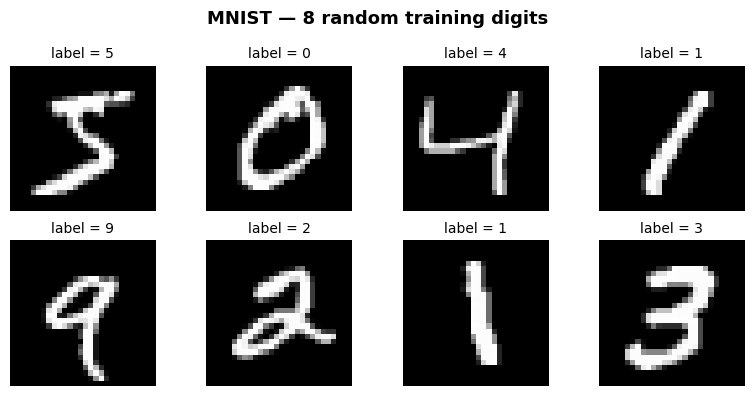

In [67]:
# Provided visualization: a few training digits
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, (img, label) in zip(axes.flat, [train_set[i] for i in range(8)]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"label = {label}", fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST — 8 random training digits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 2 — Variational Autoencoder (~35 min)

Lecture §2 derived the VAE objective by writing the log-likelihood as

$$
\log p_{\boldsymbol\phi}(\mathbf{x}) \;=\; \underbrace{\mathbb{E}_{q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{reconstruction}}
\;-\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p(\mathbf{z})\bigr]}_{\text{KL regularizer}}
\;+\; D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\bigr].
$$

The last term is the gap between our **variational posterior** $q$ and the true (intractable) posterior. It is always $\ge 0$, so the first two terms form a **lower bound** on the log-likelihood — the **ELBO**. We maximise the ELBO; equivalently, we minimise its negative:

$$
\mathcal{L} \;=\; \underbrace{-\mathbb{E}_q\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{recon loss}} \;+\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,\mathcal{N}(0,\mathbf{I})\bigr]}_{\text{closed-form KL}}.
$$

Two technical facts we will use:

- For a Bernoulli decoder over pixels in $[0, 1]$, the negative log-likelihood is **binary cross-entropy**. We work with logits and use `F.binary_cross_entropy_with_logits` for numerical stability (same lesson as `CrossEntropyLoss` on logits in Notebooks 4–7).
- For a diagonal-Gaussian encoder $q(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\boldsymbol\mu, \mathrm{diag}(\boldsymbol\sigma^2))$ against a standard-normal prior, the KL has a **closed form**:

  $$
  D_{\mathrm{KL}}\!\bigl[\mathcal{N}(\boldsymbol\mu, \boldsymbol\sigma^2)\,\Vert\,\mathcal{N}(0, \mathbf{I})\bigr]
  \;=\; -\tfrac{1}{2}\sum_d \bigl(1 + \log\sigma_d^2 - \mu_d^2 - \sigma_d^2\bigr).
  $$

We parameterise the encoder to output `log(sigma^2)` (`logvar`) rather than `sigma` directly — this keeps the variance positive without a constraint and makes the KL formula above plug in cleanly.


### Exercise 2.1 — The VAE class

Implement the `VAE` class:

- `encoder = nn.Sequential(Linear(784, 400), ReLU())`
- `fc_mu = nn.Linear(400, z_dim)` and `fc_logvar = nn.Linear(400, z_dim)` — two separate heads
- `decoder = nn.Sequential(Linear(z_dim, 400), ReLU(), Linear(400, 784))` — returns **logits**, *not* probabilities
- `reparameterize(mu, logvar)`: compute `std = (0.5 * logvar).exp()`, draw `eps ~ N(0, I)` with `torch.randn_like(std)`, return `mu + std * eps`
- `forward(x)`: flatten the image, encode, reparameterize, decode; return `(logits, mu, logvar)`

Use `z_dim=16` as the default.


In [68]:
class VAE(nn.Module):
    def __init__(self, x_dim: int = 784, h_dim: int = 400, z_dim: int = 16):
        super().__init__()
        self.x_dim = x_dim
        self.z_dim = z_dim

        # compress flattened pixels into a hidden feature vector
        self.encoder = nn.Sequential(nn.Linear(x_dim, h_dim), nn.ReLU())
        # predict latent mean per dimension
        self.fc_mu = nn.Linear(h_dim, z_dim)
        # predict latent log-variance per dimension
        self.fc_logvar = nn.Linear(h_dim, z_dim)
        # map latent code back to pixel logits
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim), nn.ReLU(), nn.Linear(h_dim, x_dim)
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # forward pass through shared encoder trunk
        h = self.encoder(x)
        # Gaussian mean of q(z|x)
        mu = self.fc_mu(h)
        # log-variance of q(z|x)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        # convert log-variance to standard deviation
        std = (0.5 * logvar).exp()
        # draw random noise for the reparameterization trick
        eps = torch.randn_like(std)
        # sample z = mu + std * eps (differentiable w.r.t. mu, std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        # map latent vector to reconstruction logits
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # flatten image batch to vectors
        x_flat = x.view(x.size(0), -1)
        # get latent distribution parameters
        mu, logvar = self.encode(x_flat)
        # draw a latent sample for the decoder
        z = self.reparameterize(mu, logvar)
        # reconstruct pixel logits
        logits = self.decode(z)
        return logits, mu, logvar


In [69]:
# Sanity check on shapes
vae = VAE().to(device)
x_sample, _ = next(iter(train_loader))
x_sample = x_sample.to(device)
logits, mu, logvar = vae(x_sample)
print(f"logits: {tuple(logits.shape)}")
print(f"mu    : {tuple(mu.shape)}")
print(f"logvar: {tuple(logvar.shape)}")
summary(vae, input_size=(1, 1, 28, 28), depth=2)


logits: (128, 784)
mu    : (128, 16)
logvar: (128, 16)


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 784]                  --
├─Sequential: 1-1                        [1, 400]                  --
│    └─Linear: 2-1                       [1, 400]                  314,000
│    └─ReLU: 2-2                         [1, 400]                  --
├─Linear: 1-2                            [1, 16]                   6,416
├─Linear: 1-3                            [1, 16]                   6,416
├─Sequential: 1-4                        [1, 784]                  --
│    └─Linear: 2-3                       [1, 400]                  6,800
│    └─ReLU: 2-4                         [1, 400]                  --
│    └─Linear: 2-5                       [1, 784]                  314,384
Total params: 648,016
Trainable params: 648,016
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.65
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.59
Estimated T

### Exercise 2.2 — The ELBO loss

Implement `elbo_loss(logits, x, mu, logvar, beta=1.0)`:

- **Reconstruction loss**: `F.binary_cross_entropy_with_logits(logits, x.view(B, -1), reduction='sum')`. Using `reduction='sum'` (over batch *and* pixels) and then dividing the final total by the batch size gives a per-image loss whose magnitude is comparable to the KL — a common pattern.
- **KL term**: closed-form, `kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum()`
- Return `(total, recon, kl)`, all averaged over batch (i.e. divide each by `B`).
- The `beta` argument scales the KL term — leave it at `1.0` for the vanilla VAE. (We will play with `beta` in the optional extension.)


In [70]:
def elbo_loss(
    logits: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    B = x.size(0)
    # pixel-wise Bernoulli NLL between decoder logits and target pixels
    recon = F.binary_cross_entropy_with_logits(
        logits, x.view(B, -1), reduction="sum"
    ) / B
    # closed-form KL between q(z|x) and N(0, I), summed over latent dims
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum() / B
    # ELBO loss = reconstruction + scaled regularizer
    total = recon + beta * kl
    return total, recon, kl


> **Question 2.1** — Why do we use `binary_cross_entropy_with_logits` instead of computing `sigmoid` followed by `binary_cross_entropy`? Mathematically the two are identical.

They are computationally different due to floating-point precision limits. Computing a sigmoid and then taking the log inside the BCE loss can lead to underflow/overflow, could result in NaN or -inf. `binary_cross_entropy_with_logits` utilizes the log-sum exponential trick.

> **Question 2.2** — Suppose you set the KL coefficient to 0 (i.e. drop the regularizer entirely). What does the model degenerate into, and what would the unconditional samples look like?

Degenerates into a standard Autoencoder. Injecting random noise at the bottlenecks. Because the KL divergence term is what forces the latent space q(z|x) to resemble the standard normal prior N(0,I), dropping it means the latent space will not be organized or continuous. Resulting in images that look like artifacts or distorted because that random noise makes the vectors fall at empty regions of the latent space, the decoder was never trained to map them to real images.

### Exercise 2.3 — Train the VAE

Reusable training helpers are provided below. Your job: pick the hyperparameters (suggested: `epochs=15`, `lr=1e-3`, Adam), run training, and record `(total, recon, kl)` for both train and test sets per epoch.


In [71]:
def train_vae_epoch(
    model: VAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.train()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        total.backward()
        optimizer.step()
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


@torch.no_grad()
def evaluate_vae(
    model: VAE,
    loader: DataLoader,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.eval()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


In [72]:
# initialize VAE, Adam (lr=1e-3, suggested), train for epochs=15 (suggested).
# Record train and test (total, recon, kl) per epoch in a `history` dict.

vae = VAE().to(device)
# adaptive first-order optimizer for VAE weights
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
vae_epochs = 30

history = {
    "train_total": [],
    "train_recon": [],
    "train_kl": [],
    "test_total": [],
    "test_recon": [],
    "test_kl": [],
}

for epoch in range(1, vae_epochs + 1):
    # one training pass with gradient updates
    train_total, train_recon, train_kl = train_vae_epoch(
        vae, train_loader, vae_optimizer, device
    )
    # evaluate on held-out data without updating weights
    test_total, test_recon, test_kl = evaluate_vae(vae, test_loader, device)
    history["train_total"].append(train_total)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["test_total"].append(test_total)
    history["test_recon"].append(test_recon)
    history["test_kl"].append(test_kl)
    print(
        f"Epoch {epoch:02d} | "
        f"train {train_total:.1f} (recon {train_recon:.1f}, kl {train_kl:.1f}) | "
        f"test {test_total:.1f}"
    )


Epoch 01 | train 163.3 (recon 147.8, kl 15.5) | test 126.4
Epoch 02 | train 121.5 (recon 100.3, kl 21.3) | test 116.2
Epoch 03 | train 115.5 (recon 93.4, kl 22.2) | test 112.6
Epoch 04 | train 112.7 (recon 90.1, kl 22.5) | test 110.6
Epoch 05 | train 110.9 (recon 88.1, kl 22.8) | test 109.4
Epoch 06 | train 109.8 (recon 86.7, kl 23.0) | test 108.5
Epoch 07 | train 108.9 (recon 85.7, kl 23.2) | test 107.8
Epoch 08 | train 108.2 (recon 84.9, kl 23.3) | test 107.5
Epoch 09 | train 107.6 (recon 84.3, kl 23.3) | test 106.9
Epoch 10 | train 107.3 (recon 83.8, kl 23.5) | test 106.6
Epoch 11 | train 106.9 (recon 83.4, kl 23.5) | test 106.1
Epoch 12 | train 106.5 (recon 83.0, kl 23.5) | test 105.9
Epoch 13 | train 106.2 (recon 82.6, kl 23.6) | test 105.6
Epoch 14 | train 105.9 (recon 82.3, kl 23.6) | test 105.6
Epoch 15 | train 105.7 (recon 82.0, kl 23.6) | test 105.2
Epoch 16 | train 105.5 (recon 81.8, kl 23.7) | test 105.0
Epoch 17 | train 105.3 (recon 81.6, kl 23.7) | test 105.0
Epoch 18 | t

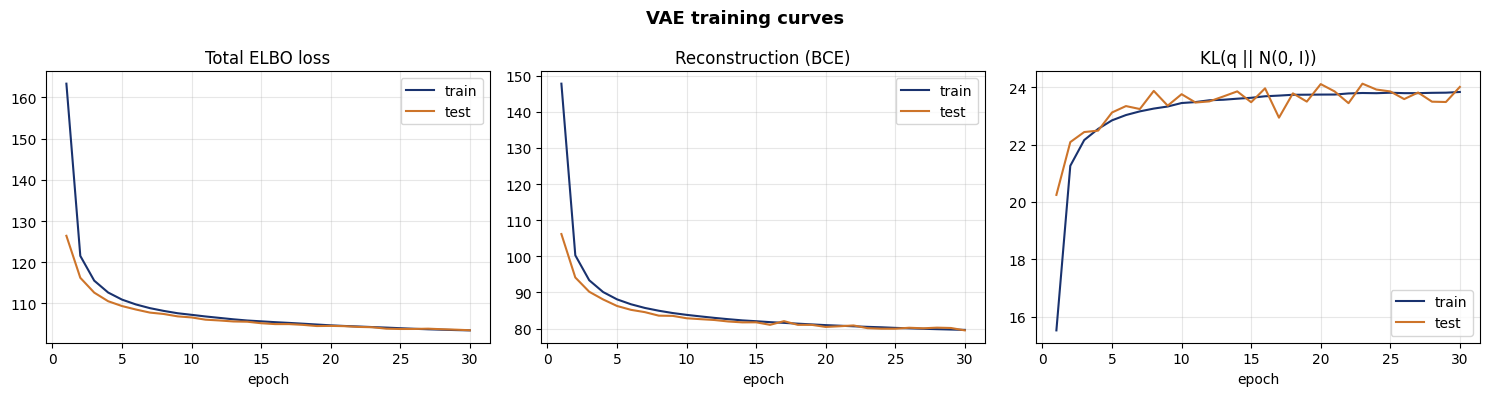

In [73]:
# Provided plot: total / recon / KL vs epoch
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_axis = range(1, vae_epochs + 1)

axes[0].plot(epochs_axis, history["train_total"], label="train", color=C1)
axes[0].plot(epochs_axis, history["test_total"], label="test", color=C3)
axes[0].set_title("Total ELBO loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, history["train_recon"], label="train", color=C1)
axes[1].plot(epochs_axis, history["test_recon"], label="test", color=C3)
axes[1].set_title("Reconstruction (BCE)"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_axis, history["train_kl"], label="train", color=C1)
axes[2].plot(epochs_axis, history["test_kl"], label="test", color=C3)
axes[2].set_title("KL(q || N(0, I))"); axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE training curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.4 — Sample from the prior

Implement `vae_sample(model, n_samples=16, z_dim=16)`:

1. Draw `z ~ N(0, I)` of shape `(n_samples, z_dim)` on the right device.
2. Decode to logits.
3. Apply `sigmoid` to get probabilities (= image pixel intensities).
4. Reshape to `(n_samples, 1, 28, 28)` and return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [74]:
@torch.no_grad()
def vae_sample(model: VAE, n_samples: int = 16, z_dim: int = 16) -> torch.Tensor:
    model.eval()
    dev = next(model.parameters()).device
    # sample latent codes from the standard normal prior
    z = torch.randn(n_samples, z_dim, device=dev)
    # decode latent codes to pixel logits
    logits = model.decode(z)
    # map logits to pixel probabilities in [0, 1]
    imgs = torch.sigmoid(logits).view(n_samples, 1, 28, 28)
    return imgs.cpu()


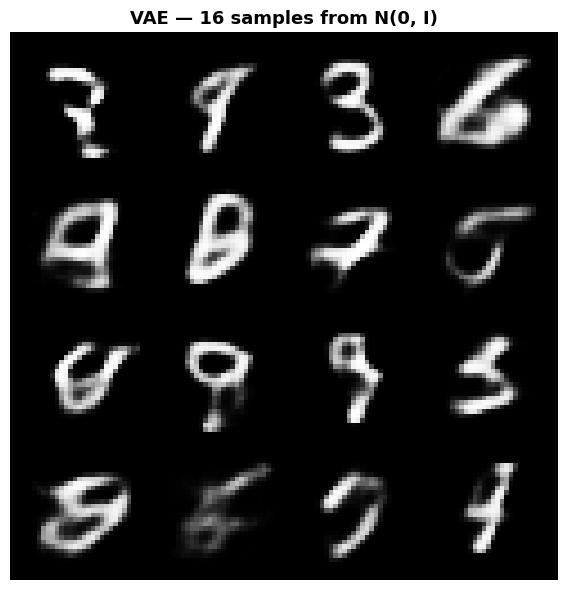

In [75]:
vae_samples = vae_sample(vae, n_samples=16)
grid = make_grid(vae_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — 16 samples from N(0, I)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.5 — Latent-space interpolation

A trained VAE should give a *smooth* latent space: walking in a straight line between two codes should produce a smooth sequence of plausible images. Implement `vae_interpolate(model, x1, x2, n_steps=8)`:

1. Encode `x1` and `x2` with the model's `encode` method and take their **means** (`mu`) — ignore the variance.
2. Linearly interpolate between the two `mu` vectors at `n_steps` evenly spaced values of $\alpha\in[0, 1]$.
3. Decode each interpolated code, sigmoid, return as a `(n_steps, 1, 28, 28)` CPU tensor.

For input, take a `0` and a `9` from the test set.


In [76]:
@torch.no_grad()
def vae_interpolate(
    model: VAE,
    x1: torch.Tensor,
    x2: torch.Tensor,
    n_steps: int = 8,
) -> torch.Tensor:
    model.eval()
    dev = next(model.parameters()).device
    # encode endpoints to latent means (ignore variance at inference)
    mu1, _ = model.encode(x1.unsqueeze(0).view(1, -1).to(dev))
    mu2, _ = model.encode(x2.unsqueeze(0).view(1, -1).to(dev))
    imgs = []
    for i in range(n_steps):
        alpha = i / (n_steps - 1) if n_steps > 1 else 0.0
        # linear blend between the two latent means
        z = (1 - alpha) * mu1 + alpha * mu2
        # decode blended code to pixel logits
        logits = model.decode(z)
        # convert logits to image intensities
        imgs.append(torch.sigmoid(logits).view(1, 1, 28, 28))
    return torch.cat(imgs, dim=0).cpu()


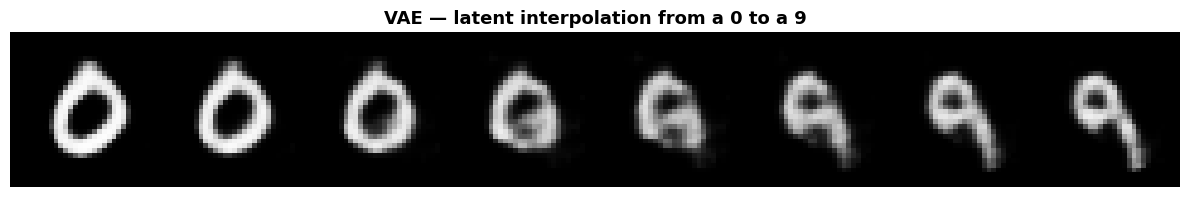

In [77]:
# Pick a 0 and a 9 from the test set
def find_first(label: int) -> torch.Tensor:
    for img, lbl in test_set:
        if lbl == label:
            return img
    raise RuntimeError(f"No example of class {label} in test set")

x_a = find_first(0)
x_b = find_first(9)

interp = vae_interpolate(vae, x_a, x_b, n_steps=8)
grid = make_grid(interp, nrow=8, padding=2).permute(1, 2, 0)
plt.figure(figsize=(12, 2))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — latent interpolation from a 0 to a 9", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 3 — DDPM diffusion model (~50 min)

DDPM ([Ho et al., 2020](https://arxiv.org/abs/2006.11239)) takes a completely different angle. There is no learned encoder — the **forward (encoding) process is fixed**: gradually add Gaussian noise over $T$ steps until any image becomes pure noise. The only thing we *learn* is the **reverse** process — undoing one noising step at a time.

The forward step is

$$
q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) \;=\; \mathcal{N}\!\bigl(\sqrt{1-\beta_t}\,\mathbf{z}_{t-1},\;\beta_t\mathbf{I}\bigr),\qquad \mathbf{z}_0 \equiv \mathbf{x}.
$$

A small bit of algebra (Prince §18.3) gives the **closed-form marginal**:

$$
q(\mathbf{z}_t \mid \mathbf{x}) \;=\; \mathcal{N}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x},\;(1-\bar\alpha_t)\,\mathbf{I}\bigr),\qquad \bar\alpha_t = \prod_{s=1}^t (1 - \beta_s).
$$

This is the practical magic: we can sample any $\mathbf{z}_t$ from $\mathbf{x}$ in **one step**, without simulating the chain.

The training objective, after a bunch of cancellations, reduces to

$$
\mathcal{L} \;=\; \mathbb{E}_{t,\,\mathbf{x},\,\boldsymbol\varepsilon}\!\left[\bigl\|\boldsymbol\varepsilon \;-\; \mathbf{f}_{\boldsymbol\phi}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x} + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon,\;t\bigr)\bigr\|^2\right]
$$

— a **plain MSE on noise prediction**. There is no adversary, no Jacobian, no ELBO gap to worry about. This simplicity is one of the main reasons diffusion has won.


### Exercise 3.1 — Build the noise schedule

Build the three buffers we will need throughout the rest of Part 3, on the right `device`:

- `betas = torch.linspace(1e-4, 0.02, T)` for `T = 1000`
- `alphas = 1.0 - betas`
- `alpha_bar = torch.cumprod(alphas, dim=0)`


In [78]:
T: int = 1000
# per-step noise variance schedule
betas = torch.linspace(1e-4, 0.02, T, device=device)
# one-minus-beta at each diffusion step
alphas = 1.0 - betas
# cumulative product of alphas (closed-form forward noising factor)
alpha_bar = torch.cumprod(alphas, dim=0)


### Exercise 3.2 — `q_sample`: one-shot forward noising

Implement `q_sample(x0, t, noise=None)`:

- `x0` shape `(B, 1, 28, 28)`, on `device`.
- `t` shape `(B,)` of integer timesteps in `[0, T-1]`.
- `noise` shape `(B, 1, 28, 28)` or `None` — if `None`, sample standard normal noise.
- Look up `alpha_bar[t]` and **reshape** it to `(B, 1, 1, 1)` so it broadcasts over the image axes.
- Return $\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon$.


In [79]:
def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor | None = None,
) -> torch.Tensor:
    if noise is None:
        # standard Gaussian noise matching the image shape
        noise = torch.randn_like(x0)
    # gather alpha_bar for each batch item's timestep
    a_bar = alpha_bar[t].view(-1, 1, 1, 1)
    # closed-form noisy sample: sqrt(a_bar)*x0 + sqrt(1-a_bar)*noise
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise


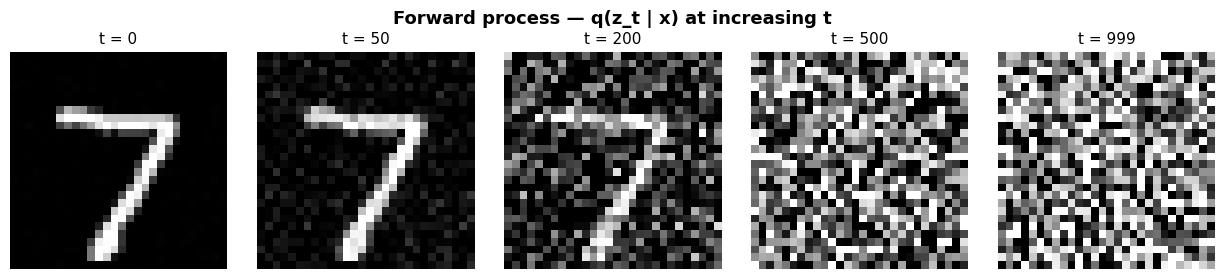

In [80]:
# Provided visualization: one digit at increasing levels of noise
img, _ = test_set[0]                            # shape (1, 28, 28), pixels in [0, 1]
x0 = (img.to(device) * 2 - 1).unsqueeze(0)      # rescale to [-1, 1] and add batch dim
ts = [0, 50, 200, 500, 999]
noisy = []
torch.manual_seed(0)
for t_val in ts:
    t = torch.tensor([t_val], device=device)
    z_t = q_sample(x0, t)
    noisy.append(z_t.squeeze(0).cpu())

fig, axes = plt.subplots(1, len(ts), figsize=(2.5 * len(ts), 2.8))
for ax, t_val, img_t in zip(axes, ts, noisy):
    ax.imshow(((img_t.clamp(-1, 1) + 1) / 2).squeeze(), cmap="gray")
    ax.set_title(f"t = {t_val}", fontsize=11)
    ax.axis("off")
plt.suptitle("Forward process — q(z_t | x) at increasing t", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### The U-Net: backbone of the reverse process

The reverse process predicts the noise that was added to produce $\mathbf{z}_t$. Its input is an image $\mathbf{z}_t$ (shape `(B, 1, 28, 28)`) plus the timestep $t$, and its output is the same shape as the input. The standard choice is a **U-Net**:

- Encoder convs downsample the spatial dimensions.
- Decoder convs upsample back, **with skip connections from the matching encoder resolution** (same as Notebook 6).
- The timestep is injected as a **sinusoidal embedding** projected through a small MLP and added to feature maps at every block.

The `SinusoidalTimeEmb` and `ResBlock` modules below are **provided** — you do not need to modify them. Your job is to assemble them into a `SmallUNet`.


In [81]:
class SinusoidalTimeEmb(nn.Module):
    """Standard sinusoidal positional encoding for the diffusion timestep."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: shape (B,) integer timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """GroupNorm + SiLU conv block with timestep injection and a residual connection."""

    def __init__(self, in_c: int, out_c: int, t_emb_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_c)
        self.t_proj = nn.Linear(t_emb_dim, out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_c)
        self.skip = nn.Conv2d(in_c, out_c, kernel_size=1) if in_c != out_c else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        # broadcast time embedding across H, W
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


### Exercise 3.3 — `SmallUNet`

Here is a version of the U-Net using the building blocks above. The layout is as follows (with `base = 32`, `t_emb_dim = 128`):

- **Time MLP**: `SinusoidalTimeEmb(t_emb_dim) → Linear(t_emb_dim, t_emb_dim*4) → SiLU → Linear(t_emb_dim*4, t_emb_dim*4)`. Pass the result of the time MLP as `t_emb` to every `ResBlock`. (So `t_emb_dim` consumed by `ResBlock` is `t_emb_dim * 4`.)
- **Stem**: `Conv2d(1, base, 3, padding=1)`.
- **Encoder**:
  - `ResBlock(base, base, t_emb_dim*4)`, save output as skip `s1`.
  - Downsample: `nn.Conv2d(base, base, 4, stride=2, padding=1)` → 28 → 14.
  - `ResBlock(base, base*2, t_emb_dim*4)`, save output as skip `s2`.
  - Downsample: `nn.Conv2d(base*2, base*2, 4, stride=2, padding=1)` → 14 → 7.
- **Bottleneck**: `ResBlock(base*2, base*4, t_emb_dim*4)`.
- **Decoder**:
  - Upsample: `nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)` → 7 → 14.
  - Concatenate with `s2` along the channel dim, then `ResBlock(base*4, base*2, t_emb_dim*4)`.
  - Upsample: `nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)` → 14 → 28.
  - Concatenate with `s1`, then `ResBlock(base*2, base, t_emb_dim*4)`.
- **Head**: `Conv2d(base, 1, 3, padding=1)` — predicts the noise (same shape as input).


In [82]:
class SmallUNet(nn.Module):
    def __init__(self, base: int = 32, t_emb_dim: int = 128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(t_emb_dim),
            nn.Linear(t_emb_dim, t_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(t_emb_dim * 4, t_emb_dim * 4),
        )
        td = t_emb_dim * 4

        # Stem
        self.stem = nn.Conv2d(1, base, kernel_size=3, padding=1)
        # Encoder
        self.enc1 = ResBlock(base, base, td)
        self.down1 = nn.Conv2d(base, base, kernel_size=4, stride=2, padding=1)
        self.enc2 = ResBlock(base, base * 2, td)
        self.down2 = nn.Conv2d(base * 2, base * 2, kernel_size=4, stride=2, padding=1)
        # Bottleneck
        self.mid = ResBlock(base * 2, base * 4, td)
        # Decoder
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ResBlock(base * 4, base * 2, td)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=4, stride=2, padding=1)
        self.dec1 = ResBlock(base * 2, base, td)
        # Head
        self.head = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        h = self.stem(x)
        s1 = self.enc1(h, t_emb)
        h = self.down1(s1)
        s2 = self.enc2(h, t_emb)
        h = self.down2(s2)
        h = self.mid(h, t_emb)
        h = self.up2(h)
        h = self.dec2(torch.cat([h, s2], dim=1), t_emb)
        h = self.up1(h)
        h = self.dec1(torch.cat([h, s1], dim=1), t_emb)
        return self.head(h)


In [83]:
# Sanity check on shapes and parameter count
unet = SmallUNet().to(device)
x_dummy = torch.randn(4, 1, 28, 28, device=device)
t_dummy = torch.randint(0, T, (4,), device=device)
out = unet(x_dummy, t_dummy)
print(f"input : {tuple(x_dummy.shape)}")
print(f"output: {tuple(out.shape)}")
n_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {n_params:,}")


input : (4, 1, 28, 28)
output: (4, 1, 28, 28)
U-Net parameters: 1,195,265


> **Question 3.1** — Why are **skip connections** essential in a diffusion U-Net? (Hint: think about what the output has to look like, not what the bottleneck stores.)

They help the network remember the fine details and sharp edges of the image. Without them, the image would get "squished" in the middle layers, and the network would forget where the exact pixels are supposed to go.

> **Question 3.2** — Why do we **add** the time embedding inside every residual block instead of just concatenating it once to the input image?

The image looks completely different depending on how much noise it has. Injecting the time step everywhere constantly reminds the network exactly how noisy the image is right now, so it knows what kind of patterns to look for.

### Exercise 3.4 — The training objective

Implement `diffusion_loss(model, x0, T)`:

1. Rescale `x0` from `[0, 1]` to `[-1, 1]` (standard DDPM practice — gives zero mean).
2. Sample timesteps `t ~ U{0, T-1}` of shape `(B,)`.
3. Sample noise `eps ~ N(0, I)` of shape `(B, 1, 28, 28)`.
4. Compute `z_t = q_sample(x0_rescaled, t, noise=eps)`.
5. Run the model: `eps_hat = model(z_t, t)`.
6. Return `F.mse_loss(eps_hat, eps)`.


In [84]:
def diffusion_loss(model: nn.Module, x0: torch.Tensor, T: int) -> torch.Tensor:
    B = x0.size(0)
    # rescale pixels to [-1, 1] for zero-mean diffusion
    x0 = x0 * 2 - 1
    # random diffusion timesteps, one per image in the batch
    t = torch.randint(0, T, (B,), device=x0.device)
    # ground-truth noise to predict
    eps = torch.randn_like(x0)
    # forward-noise the clean images in one shot
    z_t = q_sample(x0, t, noise=eps)
    # U-Net predicts the noise from noisy input + time
    eps_hat = model(z_t, t)
    # MSE between predicted and actual noise
    return F.mse_loss(eps_hat, eps)


### Exercise 3.5 — Train the DDPM

Train the U-Net. Suggested: `ddpm_epochs = 20`, `lr = 2e-4`, `AdamW`. Record the loss per epoch.


In [85]:
unet = SmallUNet().to(device)
# AdamW with weight decay for U-Net weights
ddpm_optimizer = torch.optim.AdamW(unet.parameters(), lr=2e-4)
ddpm_epochs = 30
ddpm_losses: list[float] = []

for epoch in range(1, ddpm_epochs + 1):
    unet.train()
    epoch_loss = 0.0
    n = 0
    for x, _ in train_loader:
        x = x.to(device)
        # clear accumulated gradients from the previous step
        ddpm_optimizer.zero_grad()
        # noise-prediction MSE for this batch
        loss = diffusion_loss(unet, x, T)
        # backpropagate loss through the U-Net
        loss.backward()
        # update U-Net weights
        ddpm_optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        n += x.size(0)
    avg = epoch_loss / n
    ddpm_losses.append(avg)
    print(f"DDPM epoch {epoch:02d} | loss {avg:.5f}")


DDPM epoch 01 | loss 0.08201
DDPM epoch 02 | loss 0.03753
DDPM epoch 03 | loss 0.03275
DDPM epoch 04 | loss 0.03023
DDPM epoch 05 | loss 0.02900
DDPM epoch 06 | loss 0.02789
DDPM epoch 07 | loss 0.02736
DDPM epoch 08 | loss 0.02631
DDPM epoch 09 | loss 0.02610
DDPM epoch 10 | loss 0.02591
DDPM epoch 11 | loss 0.02539
DDPM epoch 12 | loss 0.02524
DDPM epoch 13 | loss 0.02497
DDPM epoch 14 | loss 0.02447
DDPM epoch 15 | loss 0.02436
DDPM epoch 16 | loss 0.02442
DDPM epoch 17 | loss 0.02404
DDPM epoch 18 | loss 0.02425
DDPM epoch 19 | loss 0.02390
DDPM epoch 20 | loss 0.02399
DDPM epoch 21 | loss 0.02379
DDPM epoch 22 | loss 0.02362
DDPM epoch 23 | loss 0.02361
DDPM epoch 24 | loss 0.02354
DDPM epoch 25 | loss 0.02332
DDPM epoch 26 | loss 0.02328
DDPM epoch 27 | loss 0.02315
DDPM epoch 28 | loss 0.02327
DDPM epoch 29 | loss 0.02321
DDPM epoch 30 | loss 0.02305


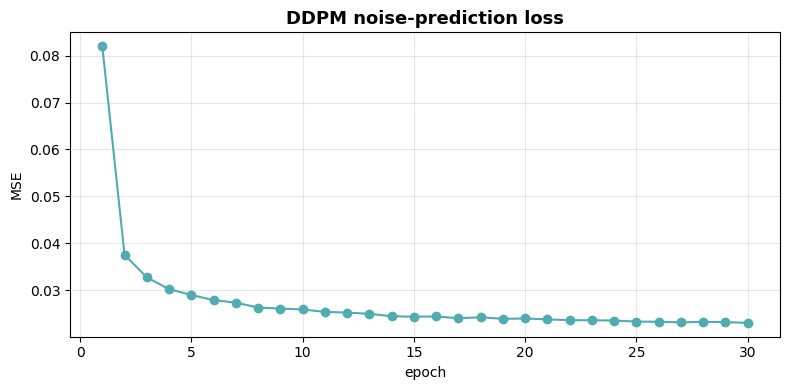

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, ddpm_epochs + 1), ddpm_losses, color=C2, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("DDPM noise-prediction loss", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Exercise 3.6 — DDPM reverse sampling

The DDPM reverse step (Ho et al. 2020, equation (11)) is

$$
\mathbf{z}_{t-1} \;=\; \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{z}_t \;-\; \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\varepsilon_{\boldsymbol\phi}(\mathbf{z}_t, t)\right) \;+\; \sigma_t\,\boldsymbol\xi,
$$

with $\sigma_t^2 = \beta_t$ and $\boldsymbol\xi\sim\mathcal{N}(0,\mathbf{I})$ for $t > 0$, and no noise added at the final step ($t = 0$).

Implement `ddpm_sample(model, n_samples, T)`:

1. Start `z = torch.randn(n_samples, 1, 28, 28, device=device)`.
2. For `t` from `T-1` down to `0`:
   - Build `t_batch = torch.full((n_samples,), t, ...)`.
   - Predict noise `eps_hat = model(z, t_batch)`.
   - Compute the mean update.
   - If `t > 0`, add `sqrt(beta_t) * noise` where `noise ~ N(0, I)`.
3. After the loop, rescale `z` from `[-1, 1]` back to `[0, 1]` and clamp.
4. Return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [87]:
@torch.no_grad()
def ddpm_sample(
    model: nn.Module,
    n_samples: int,
    T: int,
    track_every: int | None = None,
) -> tuple[torch.Tensor, list[torch.Tensor]]:
    model.eval()
    # start from pure Gaussian noise
    z = torch.randn(n_samples, 1, 28, 28, device=device)
    trajectory: list[torch.Tensor] = []
    if track_every is not None:
        # snapshot initial noisy state
        trajectory.append(((z.clamp(-1, 1) + 1) / 2).cpu())

    for t in range(T - 1, -1, -1):
        # batch of current timesteps for the U-Net
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        # predict the noise that was added at step t
        eps_hat = model(z, t_batch)
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bar[t]
        # DDPM reverse mean update (Ho et al. eq. 11)
        mean = (1 / torch.sqrt(alpha_t)) * (
            z - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_hat
        )
        if t > 0:
            # add stochastic noise except at the final step
            z = mean + torch.sqrt(beta_t) * torch.randn_like(z)
        else:
            z = mean

        if track_every is not None and (T - 1 - t) % track_every == 0:
            # save denoising progress for visualization
            trajectory.append(((z.clamp(-1, 1) + 1) / 2).cpu())

    # rescale from [-1, 1] back to [0, 1]
    samples = ((z.clamp(-1, 1) + 1) / 2).clamp(0, 1).cpu()
    if track_every is not None and (trajectory[-1] - samples).abs().max() > 1e-6:
        # append final frame only if it differs from the last snapshot
        trajectory.append(samples)
    return samples, trajectory


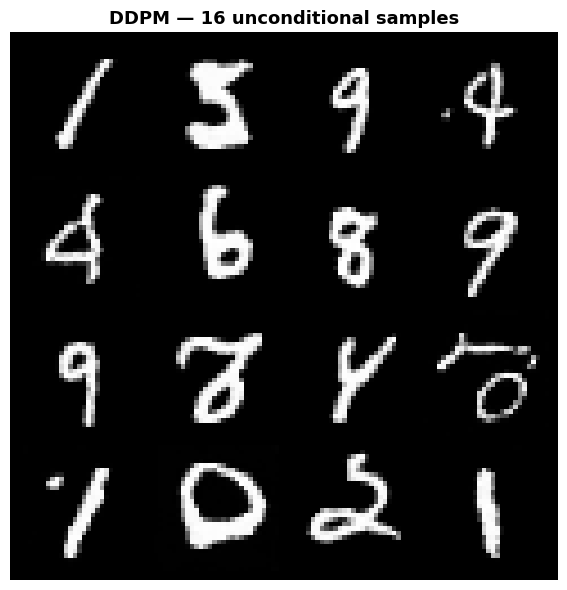

In [88]:
ddpm_samples, _ = ddpm_sample(unet, n_samples=16, T=T)
grid = make_grid(ddpm_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("DDPM — 16 unconditional samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


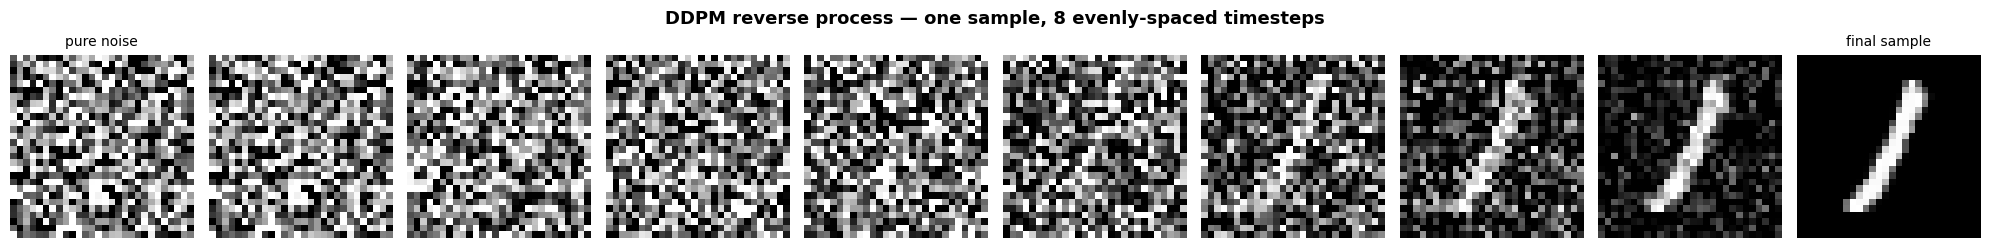

In [89]:
# Provided: visualize the reverse process for a single sample
torch.manual_seed(7)
_, traj = ddpm_sample(unet, n_samples=1, T=T, track_every=T // 8)
# `traj` is collected from t = T-1 down to t = 0 — show in that order
fig, axes = plt.subplots(1, len(traj), figsize=(2 * len(traj), 2.5))
for ax, img_t in zip(axes, traj):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
axes[0].set_title("pure noise", fontsize=10)
axes[-1].set_title("final sample", fontsize=10)
plt.suptitle("DDPM reverse process — one sample, 8 evenly-spaced timesteps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 3.3** — Sampling 16 images cost you 16 × `T` = **16,000** U-Net forward passes. Compare this with the VAE — how many forward passes did `vae_sample(model, n_samples=16)` cost? What does this say about which model you would deploy in a real-time system?

VAE "costs" 1 forward pass, even for multiple images they get gerated in the same batch. To expensive compared with DDPM 16000 passes.

I would deploy a VAE system. Because the VAE is essentially instant O(1) complexity. It can keep up with a live data stream. The DDPM is too slow for real-time use because the "wait time" for the model to iteratively denoise the image would be unacceptable for a user.


---

## Part 4 — Side-by-side comparison (~10 min)


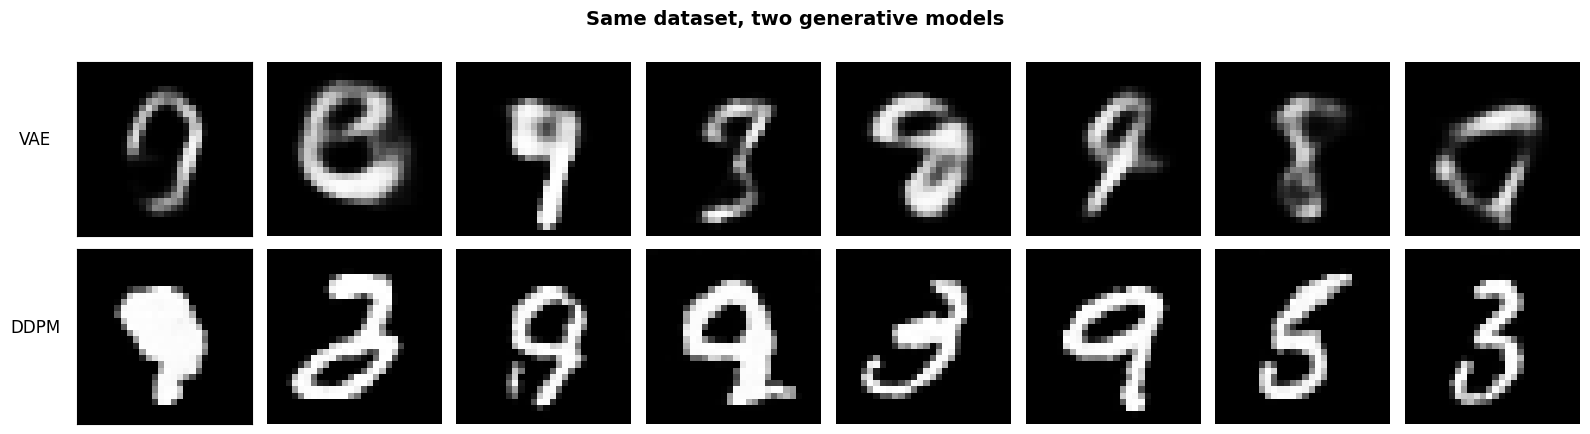

In [90]:
vae_compare = vae_sample(vae, n_samples=8)
ddpm_compare, _ = ddpm_sample(unet, n_samples=8, T=T)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, img_t in zip(axes[0], vae_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
for ax, img_t in zip(axes[1], ddpm_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
axes[0, 0].set_ylabel("VAE",  fontsize=12, rotation=0, labelpad=30); axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel("DDPM", fontsize=12, rotation=0, labelpad=30); axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
plt.suptitle("Same dataset, two generative models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 4.1** — Describe **one visible failure mode of the VAE** and **one visible failure mode of the DDPM** in your samples.

VAE Failure: The images are consistently blurry. The VAE plays it safe and averages out the pixels.

DDPM Failure: The images are sharp, but they can be weird shapes (like a mashed-up 9 and 7).

> **Question 4.2** — Map each model onto the (likelihood, sample quality, sampling speed) triangle from lecture §6. For each of the following deployments, which model would you pick and why?
>
> - (a) Anomaly detection on factory-floor camera images.

VAE. It processes images instantly and is great at flagging things that look "wrong" or out of place.

> - (b) Generating a high-resolution marketing avatar.

DDPM. It is much slower, but it creates sharp, beautiful, high-quality images, which is what matters most for marketing.

> - (c) Compressing handwritten digits into a 16-dimensional code for a downstream classifier.

VAE. The VAE is specifically built to compress data into a small bottleneck code. DDPMs don't compress data this way at all.

---

## Part 5 — Optional: HuggingFace `diffusers` with a tiny pretrained model (~25 min)

We just built a 28×28 MNIST diffusion model. Production diffusion models share the *same math* (β schedule, U-Net, noise prediction) but are pretrained on millions of images at much higher resolution, with conditional inputs (text, class), classifier-free guidance, and faster samplers.

[`diffusers`](https://huggingface.co/docs/diffusers/index) is HuggingFace's library for these models. It packages everything — the U-Net, the scheduler (DDPM, DDIM, …), the conditional inputs — into a `Pipeline` object with a single `__call__` API. We use a **tiny pretrained model** (`google/ddpm-cifar10-32`, 32×32 CIFAR-10) so the download is small and inference works on any hardware (CPU is slow but feasible; MPS/CUDA is comfortable). Stable Diffusion would teach the same lesson but needs ~6 GB of VRAM and a much larger download.


In [91]:
try:
    from diffusers import DDPMPipeline, DDIMScheduler  # noqa: F401
except ImportError:
    %pip install -q diffusers accelerate
    from diffusers import DDPMPipeline, DDIMScheduler


Note: you may need to restart the kernel to use updated packages.


c:\Users\bruno\notebook-8-generative-models-brunofrancoucu\.venv\Scripts\python.exe: No module named pip


ModuleNotFoundError: No module named 'diffusers'

### Exercise O.1 — Pretrained DDPM pipeline

Load `google/ddpm-cifar10-32`, move it to `device`, and sample 4 images with the default DDPM scheduler (1000 inference steps). Time the call. Display the four samples in a row.


In [ ]:
# YOUR CODE HERE — load `google/ddpm-cifar10-32`, sample 4 images with the default
# DDPM scheduler (num_inference_steps=1000), time the call, display the samples.
raise NotImplementedError()


### Exercise O.2 — Swap the scheduler to DDIM

`diffusers` lets you swap the **scheduler** without retraining the U-Net. **DDIM** reformulates the reverse process as a deterministic ODE that can be solved in many fewer steps.

Swap `pipe.scheduler` to a DDIM scheduler built from the same config, re-sample 4 images with `num_inference_steps=50`, time it, and display. (The U-Net weights are unchanged — only the integration scheme.)


In [ ]:
# YOUR CODE HERE — swap pipe.scheduler to a DDIM scheduler from the same config,
# re-sample with num_inference_steps=50, time the call, display.
raise NotImplementedError()


> **Question O.1** — Did the DDIM samples look meaningfully worse with **20× fewer steps**? Connect this to the ODE / deterministic-reformulation note in lecture §5.3.
> **Question O.2** — If you wanted to fine-tune `pipe.unet` on, say, 1000 custom logos at 32×32, what would you change in the pipeline you just used? (No code — just describe.)


---

## Done!

You've built two complete generative models from scratch on the same dataset and seen — visually — the trade-off the lecture spent a whole table on. A few things worth noting before you close the notebook:

- The **VAE** was light, stable, gave you a meaningful 16-d code, and produced blurry but recognisable digits.
- The **DDPM** was heavier to train and *much* slower to sample, but the samples are crisp and there is no encoder–decoder gap.
- The optional `diffusers` section gave you a feel for the production toolchain: the same math, packaged so that swapping the sampler from DDPM to DDIM is a one-line change.
- The other two families from the lecture — **GANs** and **normalizing flows** — are conceptually similar exercises if you want to keep going on your own.

Next lecture moves from generation to **reinforcement learning**, where the data distribution is shaped by the agent's own actions — a closing topic that ties together perception, modelling, and decision-making.
